# 4 — Clustering / Unsupervised Learning

Notebook ini melengkapi topik unsupervised learning pada modul. Fokusnya adalah melakukan clustering sederhana, melihat silhouette score, dan membandingkan hasil cluster dengan label asli memakai Adjusted Rand Index (ARI).

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / 'src').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.clustering import ClusterAnalyzer

DATASET_CANDIDATES = [ROOT / 'data' / 'raw' / 'customer_purchase_data.csv', ROOT / 'data' / 'raw' / 'dataset.csv']
DATASET_PATH = next((path for path in DATASET_CANDIDATES if path.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError('Tidak ada dataset yang ditemukan di data/raw/')

print('Dataset:', DATASET_PATH)

Dataset: C:\Users\bobok\modul2_datamining\data\raw\customer_purchase_data.csv


In [2]:
df = pd.read_csv(DATASET_PATH)
df.head()

,age,income,education_level,years_experience,monthly_spending,purchased
0,22,3200,SMA,1,500,0
1,25,4500,D3,2,650,0
2,28,5200,S1,4,700,0
3,30,6100,S1,5,850,1
4,33,7200,S1,7,920,1


## 1. Pilih Fitur

Untuk contoh clustering, kita gunakan fitur numerik agar perhitungan jarak lebih mudah dipahami. Kolom label `purchased` dipakai hanya untuk evaluasi tambahan ARI, bukan untuk melatih clustering.

In [3]:
target_col = 'purchased' if 'purchased' in df.columns else df.columns[-1]
feature_cols = df.select_dtypes(include=['number']).columns.tolist()
if target_col in feature_cols:
    feature_cols.remove(target_col)

print('Target label:', target_col)
print('Feature columns:', feature_cols)

y_true = df[target_col] if target_col in df.columns else None
clusterer = ClusterAnalyzer()
X_scaled = clusterer.prepare_features(df, columns=feature_cols, fit=True)
X_scaled.head()

Target label: purchased
Feature columns: ['age', 'income', 'years_experience', 'monthly_spending']


,age,income,years_experience,monthly_spending
0,-1.653846,-1.680064,-1.480535,-1.555720
1,-1.241758,-1.154539,-1.260218,-1.028238
2,-0.829670,-0.871564,-0.819582,-0.852411
3,-0.554945,-0.507738,-0.599264,-0.324929
4,-0.142857,-0.063063,-0.158629,-0.078771


In [4]:
# Cari jumlah cluster terbaik berdasarkan silhouette score
best_k_table = clusterer.find_best_k(X_scaled, k_range=range(2, 6), y_true=y_true)
best_k_table

,k,silhouette,ari
0,2,0.590281,0.335813
1,3,0.560719,0.536719
2,4,0.490625,0.309019
3,5,0.464386,0.226674


In [5]:
# Latih KMeans dengan jumlah cluster terbaik
best_k = int(best_k_table.iloc[0]['k'])
labels = clusterer.fit_kmeans(X_scaled, n_clusters=best_k)
metrics = clusterer.evaluate_clustering(X_scaled, labels, y_true=y_true)
metrics

{'silhouette': 0.590280732261483, 'ari': 0.33581296493092455}

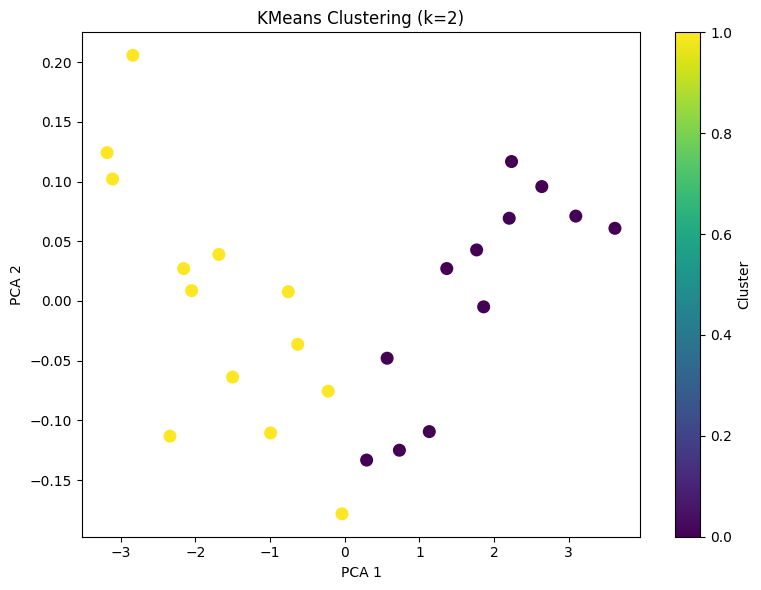

In [6]:
# Visualisasi sederhana 2D memakai PCA
X_2d = clusterer.reduce_to_2d(X_scaled)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', s=70)
plt.title(f'KMeans Clustering (k={best_k})')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## Catatan untuk Mahasiswa

- Silhouette score dipakai untuk melihat seberapa rapat cluster terbentuk.
- ARI dipakai hanya kalau label asli tersedia, jadi cocok untuk evaluasi tambahan.
- Untuk clustering murni, label asli tidak wajib dipakai saat training.
- Topik K-Fold dan GridSearchCV tetap ada di bagian modeling supervised pada [3_modeling.ipynb](3_modeling.ipynb).